In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression, load_diabetes
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [11]:
data = load_diabetes()

In [2]:
X, y = load_diabetes(return_X_y=True)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# How coefficients are affected

In [44]:
coefs = []
r2 = []
alphas = [0, 0.1, 1, 5]
for i in alphas:
    ls = Lasso(alpha=i)
    ls.fit(X_train, y_train)
    coefs.append(ls.coef_)
    r2.append(r2_score(y_test, ls.predict(X_test)))

/Volumes/SSD/Work/Clones/machine-learning/env/lib/python3.14/site-packages/sklearn/base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


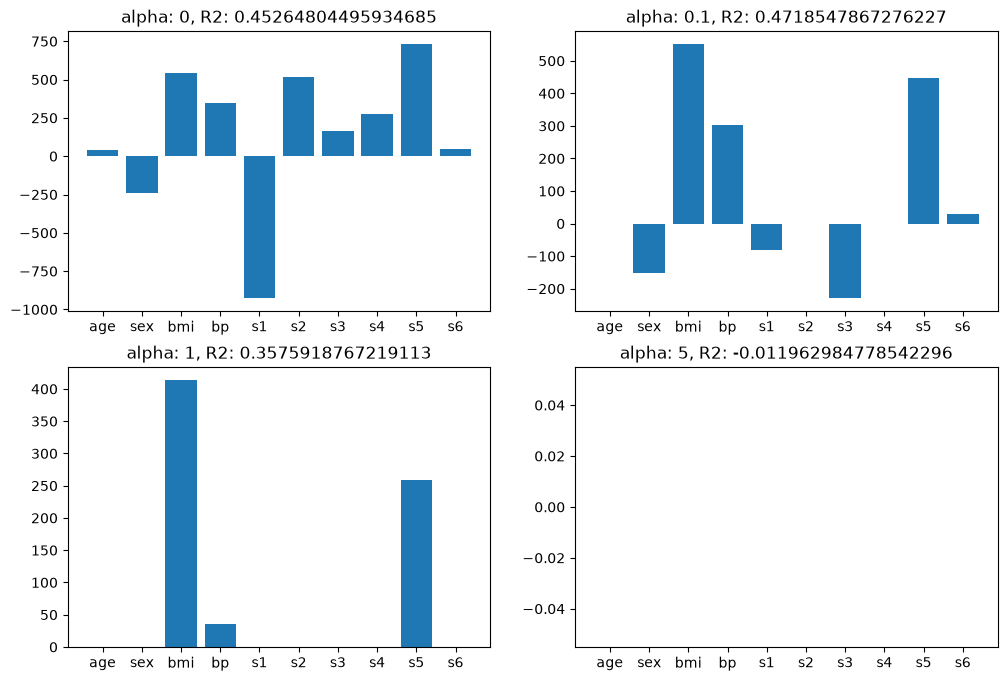

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, ax in enumerate(axes.flatten()):
    ax.bar(data.feature_names, coefs[i])
    ax.set_title(f'alpha: {alphas[i]}, R2: {r2[i]}')